In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from typing import Dict, List, Tuple, Optional
import logging
from pathlib import Path
from tqdm import tqdm
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix
)
import cv2
import seaborn as sns
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
import wandb
import random
%matplotlib inline

In [2]:
config = {
    'data_dir': '/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset',  
    'batch_size': 32,
    'learning_rate': 0.00001,
    'epochs': 50,
    'num_heads': 4,
    'key_dim': 16,
    'dropout': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
    }

In [3]:
class LungCancerDataset(Dataset):
    
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.classes = ['Bengin cases', 'Malignant cases', 'Normal cases']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.images = []
        self.labels = []

        # Load all images and labels
        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            if os.path.exists(class_dir):
                for img_file in os.listdir(class_dir):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(class_dir, img_file))
                        self.labels.append(self.class_to_idx[class_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
class CLAHETransform:
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)"""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, image):
        if isinstance(image, Image.Image):
            image = np.array(image)

        # Convert to LAB and apply CLAHE to L channel
        if len(image.shape) == 3:  
            lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            lab[:,:,0] = clahe.apply(lab[:,:,0])
            image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        else:  
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            image = clahe.apply(image)

        return Image.fromarray(image)

def get_data_transforms():
    train_transforms = transforms.Compose([
        # CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),   # CLAHE
        transforms.Resize((224, 224)),                           # Resize
        transforms.RandomRotation(15),                           # Rotation
        transforms.RandomAffine(degrees=0,                       # Shift, zoom, shear
                                translate=(0.1, 0.1), 
                                scale=(0.9, 1.1), 
                                shear=10, 
                                fill=0),                        # fill pixels with 0 (black)
        transforms.RandomHorizontalFlip(p=0.5),                  # Flip
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])
    ])

    test_transforms = transforms.Compose([
        # CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),   # CLAHE
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])
    ])

    return train_transforms, test_transforms




In [5]:
train_transforms, test_transforms = get_data_transforms()
train_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(0.9, 1.1), shear=[-10.0, 10.0])
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

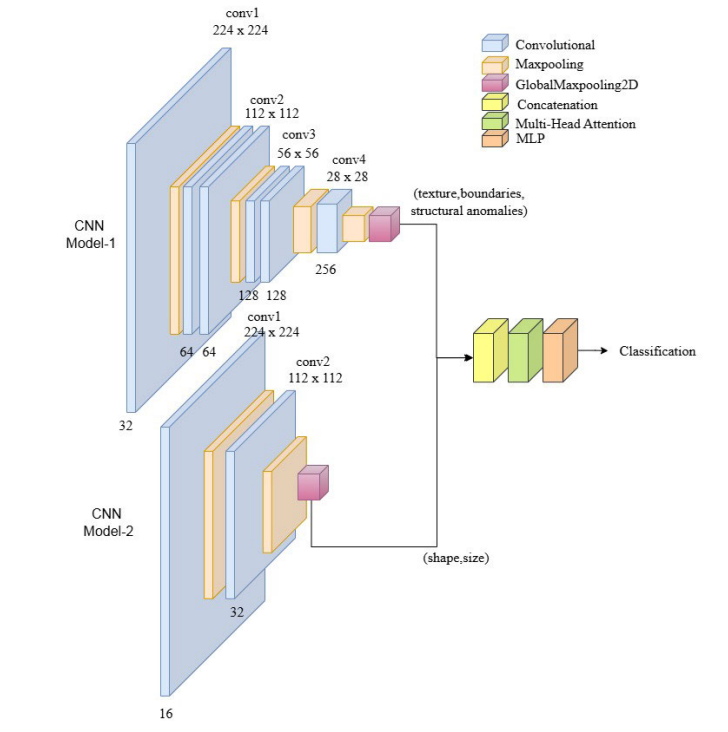

In [7]:
class CNN_Model1(nn.Module):
    def __init__(self,inp_chn = 3, out_chn=32):
        super(CNN_Model1,self).__init__()
        self.conv1 = nn.Conv2d(inp_chn,out_chn,kernel_size=3,padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(out_chn,out_chn*2,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(out_chn*2,out_chn*2,kernel_size=3,padding=1)

        self.conv4 = nn.Conv2d(out_chn*2,out_chn*4,kernel_size=3,padding=1)
        self.conv5= nn.Conv2d(out_chn*4,out_chn*4,kernel_size=3,padding=1)
        
        self.conv6 = nn.Conv2d(out_chn*4,out_chn*8,kernel_size=3,padding=1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self,x):
        # print(x.shape)
        x = self.relu(self.conv1(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv2(x))
        # print(x.shape)
        x = self.relu(self.conv3(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv4(x))
        # print(x.shape)
        x = self.relu(self.conv5(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv6(x))
        # print(x.shape)
        x = self.global_max_pool(x)
        # print(x.shape)

        # print(x.view(x.shape[0],-1).shape)
        return x
        # return x.view(x.shape[0],-1)

class CNN_Model2(nn.Module):
    def __init__(self,inp_chn = 3, out_chn=16):
        super(CNN_Model2,self).__init__()
        self.conv1 = nn.Conv2d(inp_chn,out_chn,kernel_size=3,padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(out_chn,out_chn*2,kernel_size=3,padding=1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self,x):
        # print(x.shape)
        x = self.relu(self.conv1(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.relu(self.conv2(x))
        # print(x.shape)
        x = self.pool(x)
        # print(x.shape)
        x = self.global_max_pool(x)
        # print(x.shape)
        # print(x.view(x.shape[0],-1).shape)
        return x.view(x.shape[0],-1)

In [9]:
# cnn model1 testing
image = Image.open("/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases/Bengin case (1).jpg")
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor()
])
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

testmodel = CNN_Model1()
testmodel.eval() 

with torch.no_grad():
    output1 = testmodel(image_tensor)
    print(output1.shape)
    


torch.Size([1, 256, 1, 1])


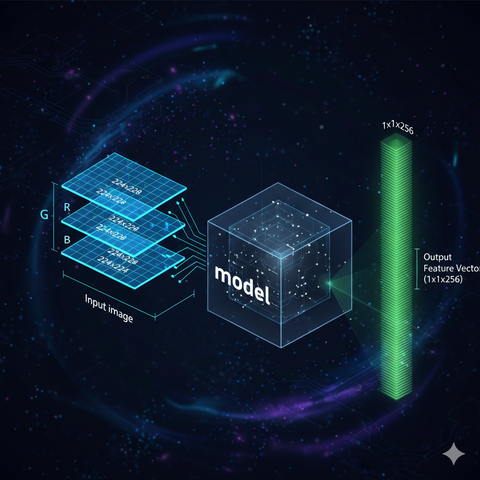
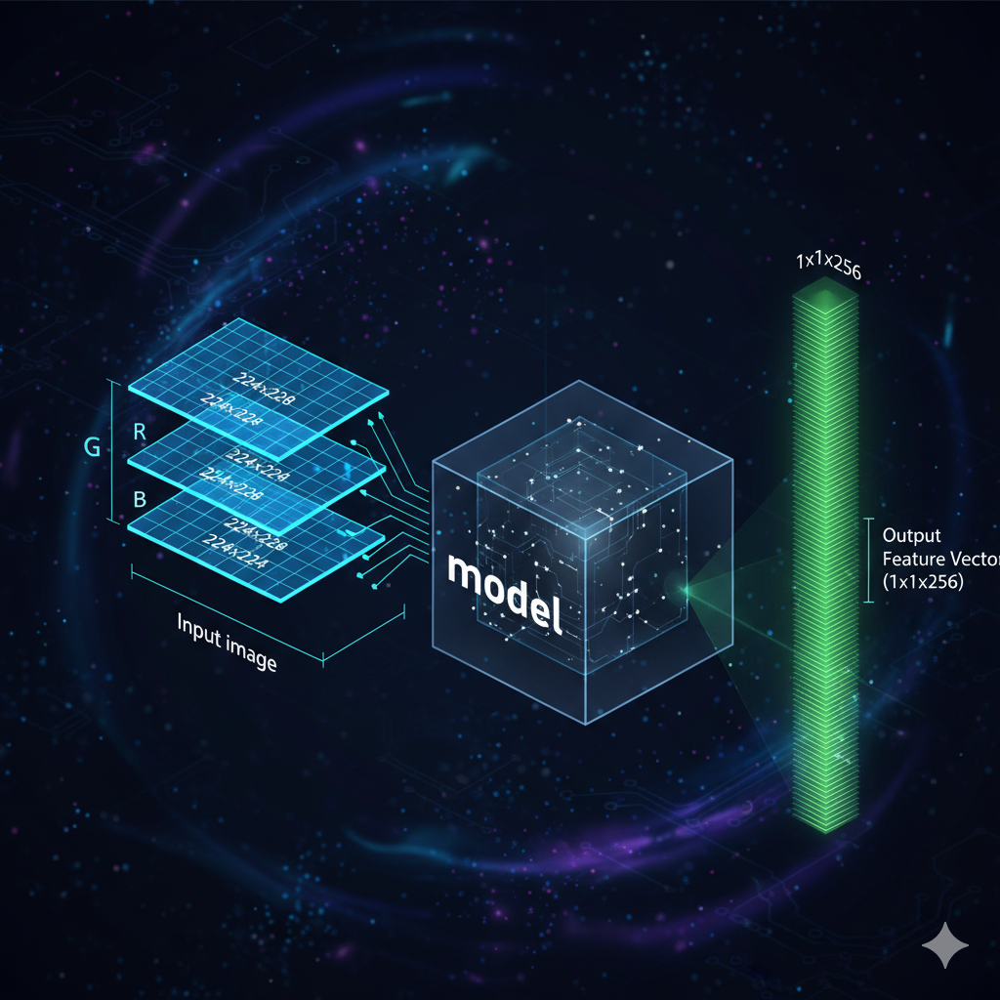
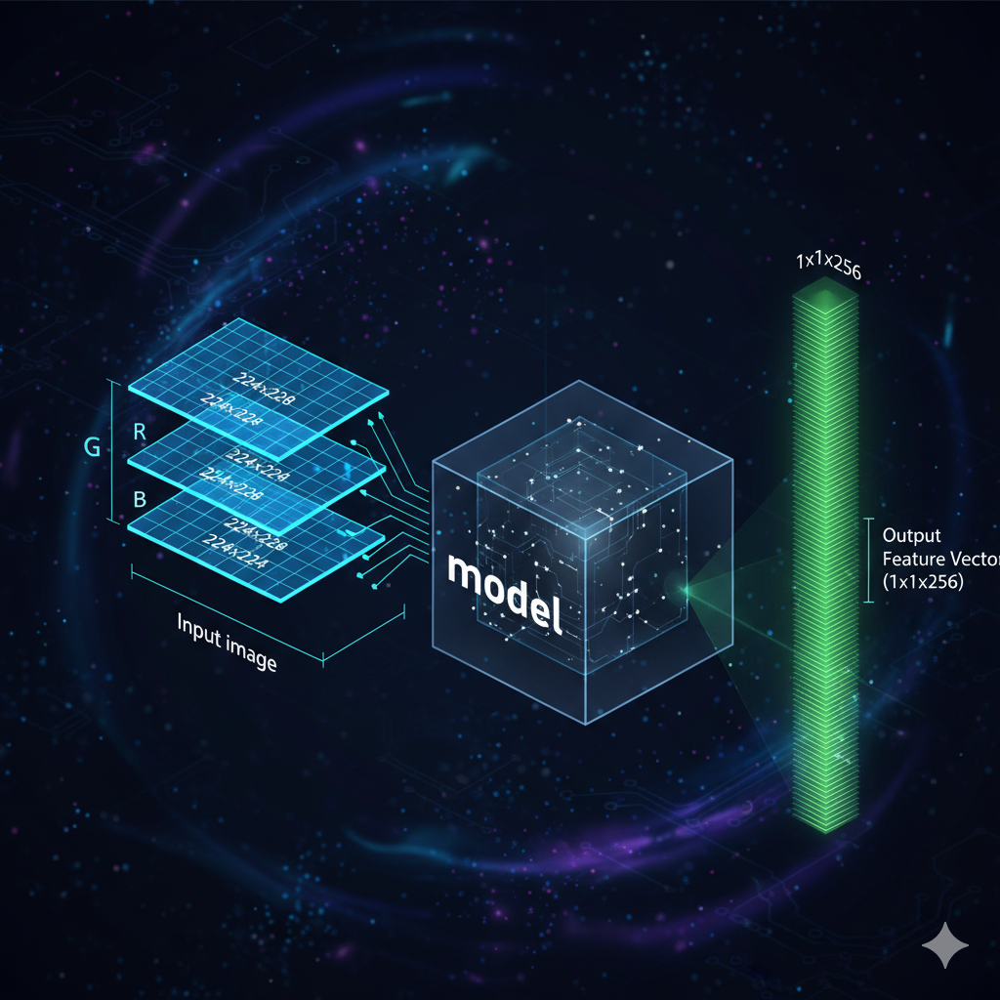
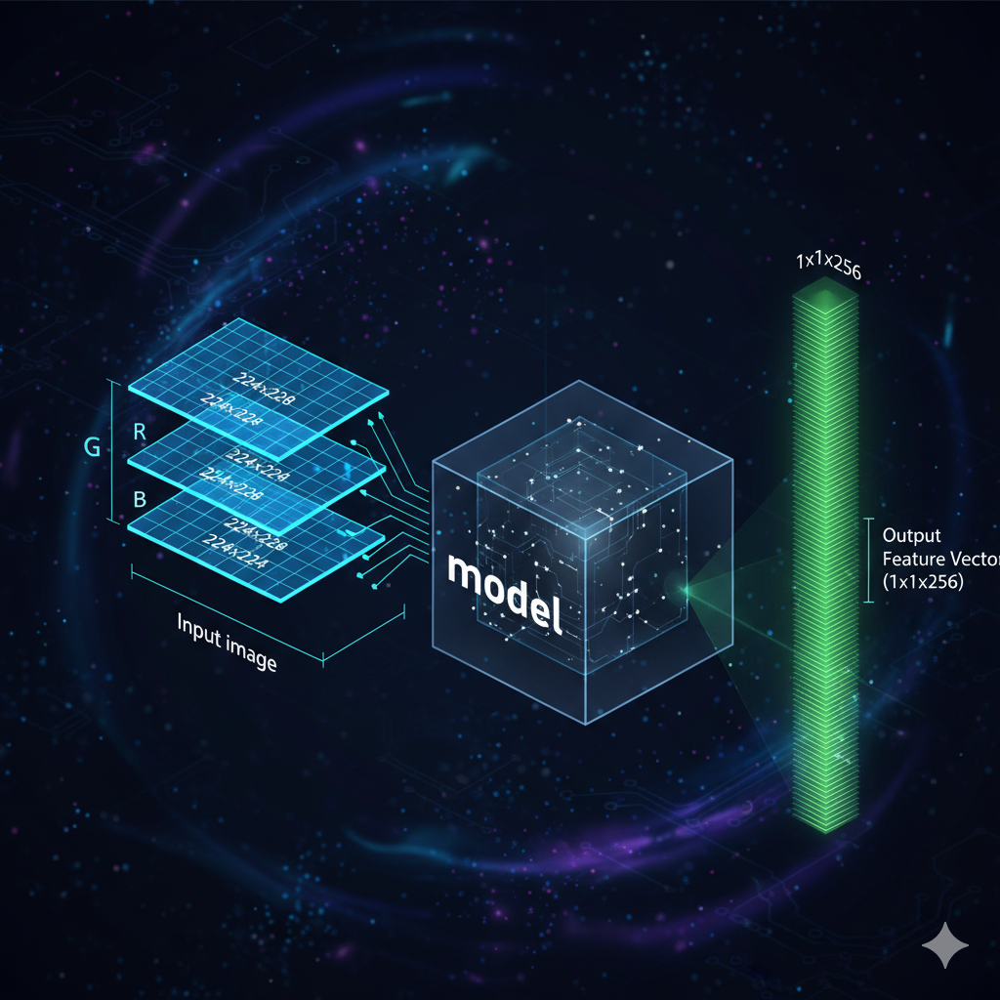
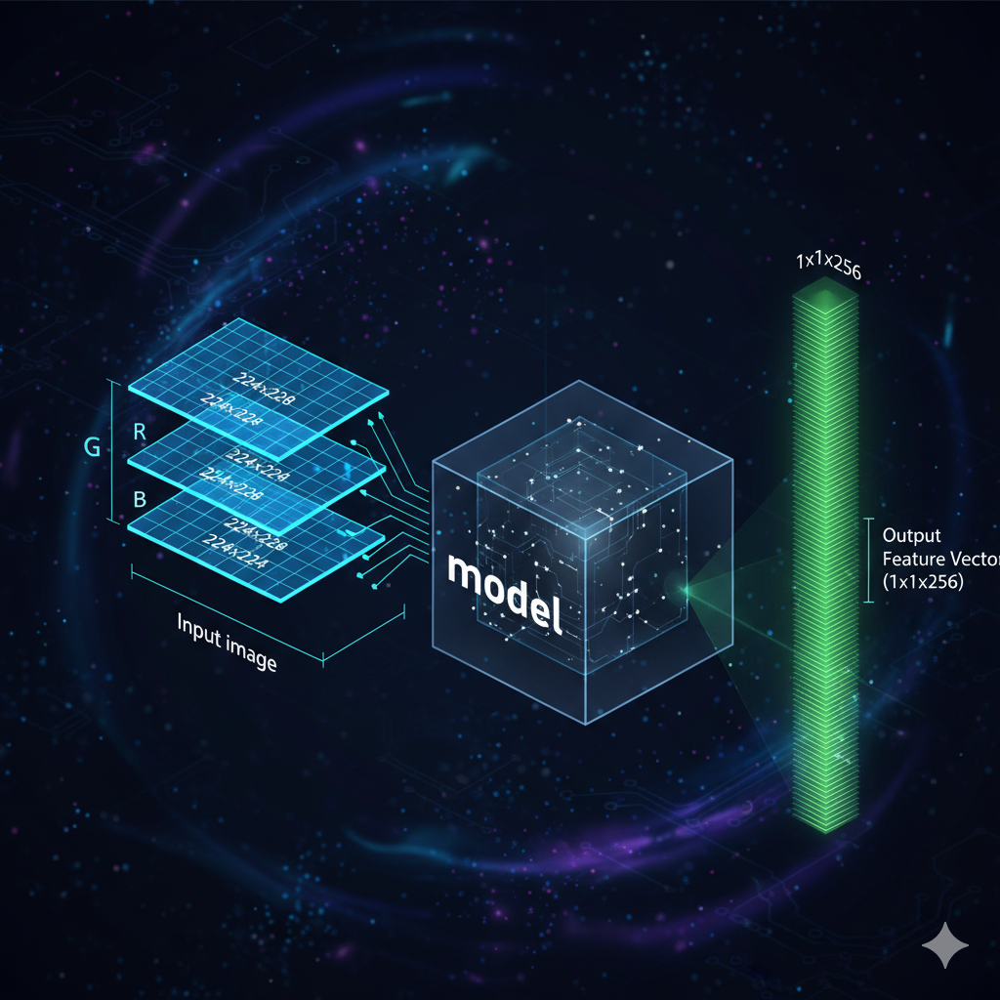
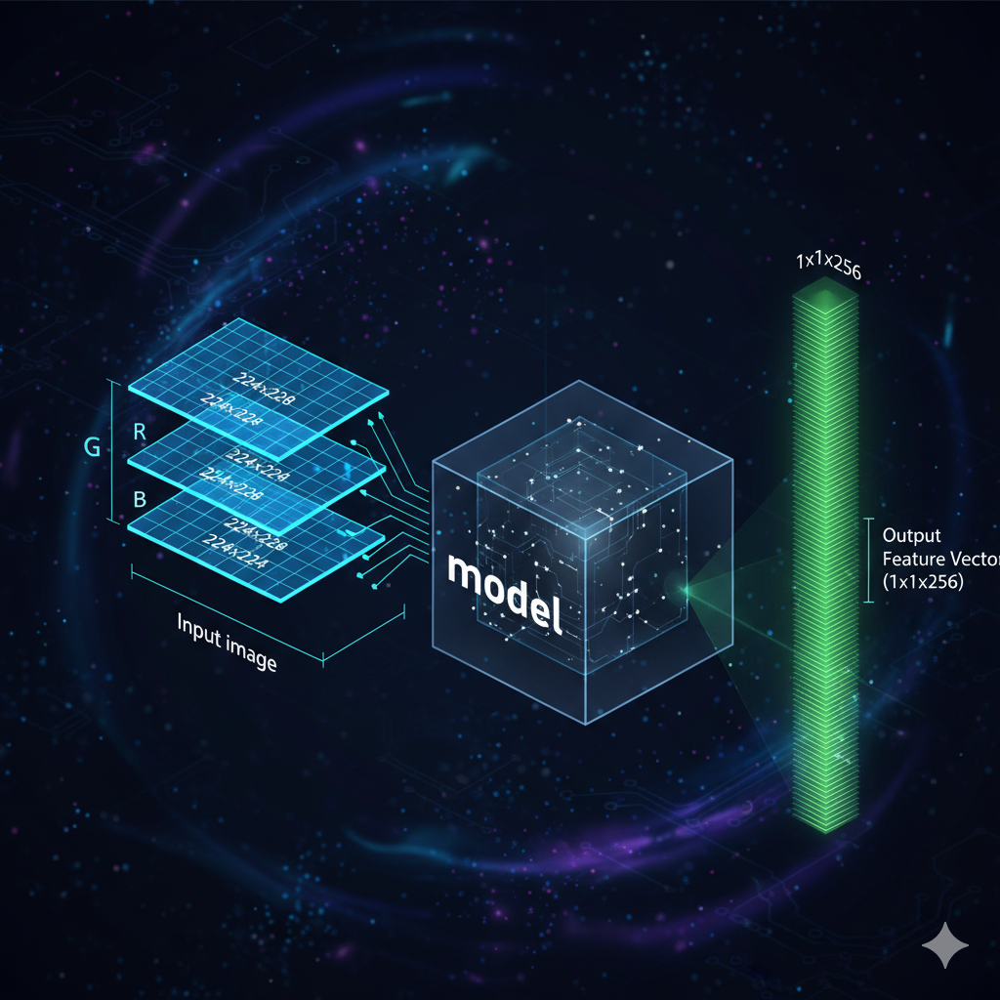
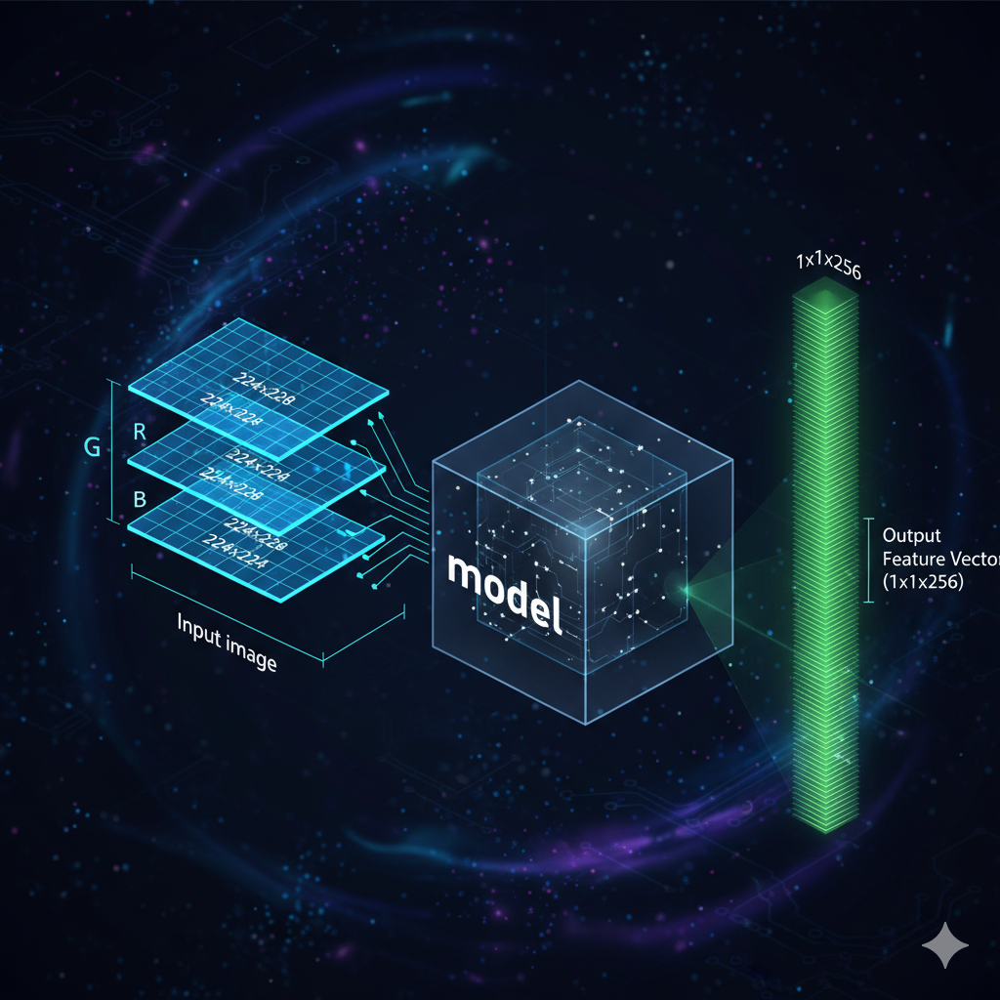
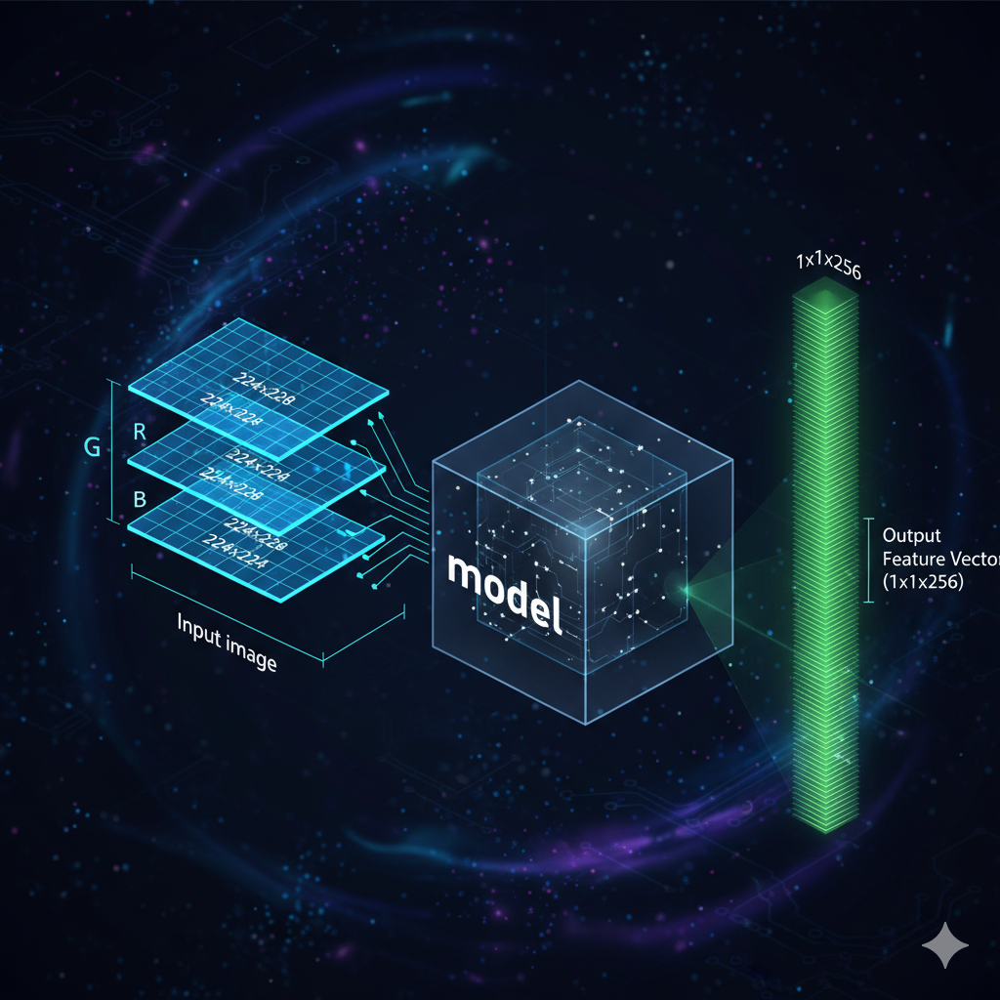

In [8]:
# # cnn model2 testing

# image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
# # print(image_tensor.shape)
# testmodel = CNN_Model2()
# testmodel.eval() 

# with torch.no_grad():
#     output2 = testmodel(image_tensor)
#     # print(output.shape)


In [9]:
# output1.shape

In [10]:
# x = torch.rand((3,3,3))
# print(x.shape)
# print(x.view(3,-1).shape)

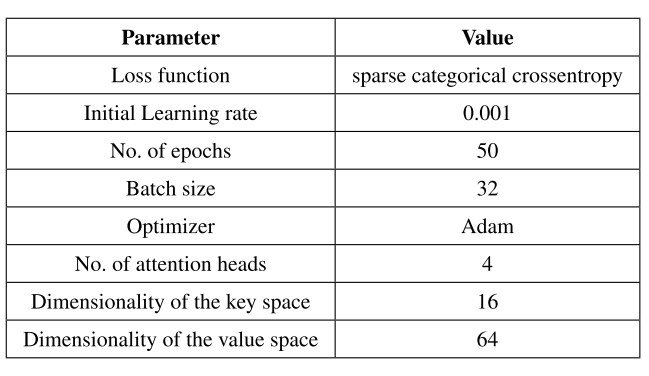
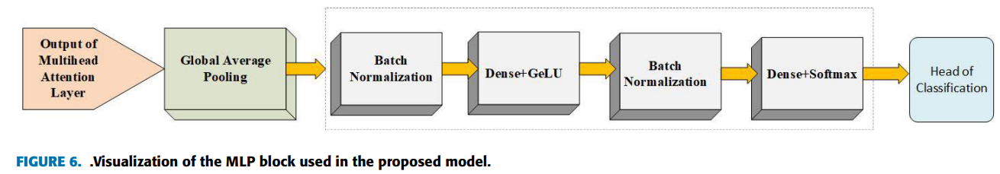

In [11]:
class MainModel(nn.Module):
    def __init__(self, num_classes=3, num_heads=4, key_dim=16, num_tokens=4, dropout_p=config['dropout']):
        super(MainModel, self).__init__()
        self.cnn1 = CNN_Model1()              # B × 256
        self.cnn2 = CNN_Model2()              # B × 32
        concat_dim = 256 + 32                 # 288 per paper

        # Attention width per PyTorch: embed_dim = num_heads * key_dim = 64
        embed_dim = num_heads * key_dim       # mirrors heads=4, key_dim=16 in paper
        self.embed_dim = embed_dim
        self.num_tokens = num_tokens

        # Project 288 → (T * E), then reshape to (B, T, E) for MHA
        self.feature_projection = nn.Linear(concat_dim, num_tokens * embed_dim)

        # Two stacked MHA layers (paper uses two)
        self.mha1 = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=0.1, batch_first=True)
        self.mha2 = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=0.1, batch_first=True)

        # MLP head mirrors: GAP1D → BN → Dense(256) → GELU → BN → Dropout → Dense(3)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.batch_norm1 = nn.BatchNorm1d(embed_dim)
        self.dense1 = nn.Linear(embed_dim, 256)
        self.gelu = nn.GELU()
        self.batch_norm2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout_p)
        self.ffn = nn.Linear(256, num_classes)

    def forward(self, x):
        f1 = self.cnn1(x)                                    # B × 256
        f2 = self.cnn2(x)                                    # B × 32
        concat_features = torch.cat([f1, f2], dim=1)         # B × 288

        proj = self.feature_projection(concat_features)      # B × (T*E)
        tokens = proj.view(proj.size(0), self.num_tokens, self.embed_dim)  # B × T × E

        attn_out1, attn_w1 = self.mha1(tokens, tokens, tokens)             # B × T × E
        attn_out2, attn_w2 = self.mha2(attn_out1, attn_out1, attn_out1)    # B × T × E

        x = attn_out2.transpose(1, 2)                        # B × E × T
        x = self.global_avg_pool(x).squeeze(-1)              # B × E

        x = self.batch_norm1(x)
        x = self.dense1(x)
        x = self.gelu(x)
        x = self.batch_norm2(x)
        x = self.dropout(x)
        logits = self.ffn(x)
        # Optionally return both attention maps
        return logits, (attn_w1, attn_w2)

In [12]:
model = MainModel()

In [13]:
def model_summary(model):
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    total_size = sum(p.numel() * p.element_size() for p in model.parameters())
    print(f"Total params: {total_params:,}")
    print(f"Model size (params only): {total_size/1024**2:.2f} MB")
    for name, param in model.named_parameters():
        print(f"{name:30} | dtype={param.dtype} | shape={tuple(param.shape)} | size={param.numel() * param.element_size() / 1024:.2f} KB")

model_summary(model)


MainModel(
  (cnn1): CNN_Model1(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (global_max_pool): AdaptiveMaxPool2d(output_size=1)
  )
  (cnn2): CNN_Model2(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (global_max_pool): AdaptiveMaxPool

In [14]:
def train_model(model, train_loader, val_loader, num_epochs=1, learning_rate=0.001, device='cuda'):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    # Track best validation accuracy
    best_val_acc = 0.0
    best_epoch = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for data, targets in tqdm(train_loader, desc=f'Training Epoch {epoch+1}'):
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs, _ = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                outputs, _ = model(data)
                loss = criterion(outputs, targets)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total

        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Check if this is the best model so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            # Save the best model
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': avg_val_loss,
                'train_acc': train_acc,
                'train_loss': avg_train_loss
            }, 'best_model.pth')
            print(f'✓ New best model saved! Val Acc: {val_acc:.2f}%')

        # Simple epoch output
        print(f'Epoch {epoch+1:2d}: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        # Basic wandb logging
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc": train_acc,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "best_val_acc": best_val_acc
        })

    # Print best model info
    print(f'\nTraining completed!')
    print(f'Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.2f}%')
    
    return train_losses, val_losses, train_accuracies, val_accuracies

def load_best_model(model, device='cuda'):
    """Load the saved best model"""
    checkpoint = torch.load('best_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f'Loaded best model from epoch {checkpoint["epoch"]}')
    print(f'Best validation accuracy: {checkpoint["val_acc"]:.2f}%')
    
    return model

def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data, targets in tqdm(test_loader, desc='Testing'):
            data, targets = data.to(device), targets.to(device)
            outputs, _ = model(data)
            probs = F.softmax(outputs, dim=1)
            
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')
    auc = roc_auc_score(all_targets, np.array(all_probs), multi_class='ovr', average='weighted')

    # Simple results display
    print(f'\nTest Results:')
    print(f'Accuracy:  {accuracy*100:.2f}%')
    print(f'Precision: {precision*100:.2f}%')
    print(f'Recall:    {recall*100:.2f}%')
    print(f'F1-Score:  {f1*100:.2f}%')
    print(f'AUC:       {auc*100:.2f}%')

    # Log to wandb
    wandb.log({
        "test_accuracy": accuracy * 100,
        "test_precision": precision * 100,
        "test_recall": recall * 100,
        "test_f1": f1 * 100,
        "test_auc": auc * 100
    })

    # Simple confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    wandb.log({"confusion_matrix": wandb.Image(plt)})
    plt.show()

    return accuracy, precision, recall, f1, auc

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(train_accuracies, 'b-', label='Train Acc', linewidth=2)
    ax2.plot(val_accuracies, 'r-', label='Val Acc', linewidth=2)
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Mark best validation accuracy
    best_val_idx = np.argmax(val_accuracies)
    ax2.scatter(best_val_idx, val_accuracies[best_val_idx], 
                color='red', s=100, marker='*', zorder=5, 
                label=f'Best: {val_accuracies[best_val_idx]:.2f}%')
    ax2.legend()

    plt.tight_layout()
    wandb.log({"training_curves": wandb.Image(plt)})
    plt.show()

In [15]:
from torch.utils.data import Subset

class SubsetWithTransform(Subset):
    def __init__(self, dataset, indices, transform=None):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, label = self.dataset[real_idx]    # NOTE: full dataset should have transform=None
        if self.transform:
            image = self.transform(image)
        return image, label


full_dataset = LungCancerDataset(config['data_dir'], transform=None)

n = len(full_dataset)
train_size = int(0.8 * n)
test_size = n - train_size

perm = torch.randperm(n)
train_indices = perm[:train_size].tolist()
test_indices  = perm[train_size:].tolist()

train_dataset = SubsetWithTransform(full_dataset, train_indices, transform=train_transforms)
test_dataset  = SubsetWithTransform(full_dataset, test_indices,  transform=test_transforms)


In [16]:
class TransformSubset(Dataset):
    """Wrapper to apply different transforms to a subset"""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
    def __len__(self):
        return len(self.subset)


# Get transforms
train_transforms, test_transforms = get_data_transforms()

# Load dataset WITHOUT transforms initially
print("Loading dataset...")
full_dataset = LungCancerDataset(config['data_dir'], transform=None)

# Get indices for stratified split
indices = list(range(len(full_dataset)))
labels = full_dataset.labels

# Stratified split to maintain class distribution
train_indices, test_indices = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=labels, 
    random_state=42
)

# Create subsets
train_subset = Subset(full_dataset, train_indices)
test_subset = Subset(full_dataset, test_indices)

# Wrap subsets with transforms
train_dataset = TransformSubset(train_subset, transform=train_transforms)
test_dataset = TransformSubset(test_subset, transform=test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], 
                         shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], 
                        shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Loading dataset...
Train samples: 877
Test samples: 220


In [ ]:

# Initialize Weights & Biases
wandb.init(
    project="base_ccal",
    name="base_model_training",
    config=config
)




# Create model
print("Creating CCAL model...")
model = MainModel(
    num_classes=3,
    num_heads=config['num_heads'],
    key_dim=config['key_dim'],
    dropout_p = config['dropout']
)

print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Log model architecture
wandb.watch(model, log="all", log_freq=100)

# Log model info to W&B
wandb.log({
    "total_parameters": sum(p.numel() for p in model.parameters()),
    "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "dataset_size": len(full_dataset),
    "train_size": train_size,
    "test_size": test_size,
})


# Train model
print("Starting training...")
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, test_loader, 
    num_epochs=config['epochs'], 
    learning_rate=config['learning_rate'],
    device=config['device']
)

# # Plot training history
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

# Evaluate on test set
print("Evaluating model...")
accuracy, precision, recall, f1, auc = evaluate_model(model, test_loader, device=config['device'])

# Save model
torch.save(model.state_dict(), 'base_ccal.pth')
print("Model saved as 'base_ccal.pth'")

# Save model artifact to W&B
artifact = wandb.Artifact('base_ccal', type='model')
artifact.add_file('base_ccal.pth')
wandb.log_artifact(artifact)

# Finish W&B run
wandb.finish()
